# Household Power Consumption Time Series Forecasting

**A complete data science pipeline: from raw smart-meter readings to a working forecasting model.**

---

## 1. Problem Statement and Objective

### Problem Statement
Household electricity consumption fluctuates daily based on lifestyle, weather, and appliance usage. Utility companies and homeowners benefit greatly from being able to **forecast future power consumption**, whether for grid load balancing, cost planning, or energy-saving interventions.

This project uses the **Household Power Consumption** dataset, minute-level electrical readings from a single house near Paris, France, to build a model that forecasts **daily average Global Active Power** consumption.

### Objective
1. Load and clean a large-scale, minute-resolution smart meter dataset.
2. Aggregate the data into a meaningful time series (daily granularity).
3. Explore consumption patterns (trends, seasonality, weekday/weekend effects, correlations).
4. Engineer time-series features (lags, rolling statistics, calendar features).
5. Train and evaluate multiple regression models to forecast next-day power consumption.
6. Compare model performance and extract actionable insights.

### Dataset Source
UCI Machine Learning Repository *Individual household electric power consumption* Data Set.

## 2. Dataset Description and Loading

**Columns:**
| Column | Description |
|---|---|
| `Date` | Date in dd/mm/yyyy format |
| `Time` | Time in hh:mm:ss format |
| `Global_active_power` | Household global minute-averaged active power (kilowatts) |
| `Global_reactive_power` | Household global minute-averaged reactive power (kilowatts) |
| `Voltage` | Minute-averaged voltage (volts) |
| `Global_intensity` | Household global minute-averaged current intensity (amperes) |
| `Sub_metering_1` | Energy sub-metering No. 1 kitchen (Wh) |
| `Sub_metering_2` | Energy sub-metering No. 2 laundry room (Wh) |
| `Sub_metering_3` | Energy sub-metering No. 3 water heater & AC (Wh) |

The data is recorded at **1-minute resolution**, giving over a million rows spanning roughly two years.

In [1]:
%pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 468.7 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.5 MB 468.7 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.5 MB 468.7 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.5 MB 512.9 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.5 MB 512.9 kB/s eta 0:00:18
   ---- ----------------------------------- 1.0/9.5 MB 534.0 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.5 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\yasha\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

In [2]:
# Load the dataset
# '?' is used in the raw file to denote missing readings, so we treat it as NaN
df = pd.read_csv('household_power_consumption.csv', sep=',', na_values='?', low_memory=False)

print(f"Shape: {df.shape}")
df.head()

Shape: (1048575, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  float64
 7   Sub_metering_2         1044506 non-null  float64
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(7), object(2)
memory usage: 72.0+ MB


In [4]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


## 3. Data Cleaning and Preprocessing

Steps performed:
1. Combine `Date` + `Time` into a proper `DateTime` index.
2. Check and handle missing values (`?` → `NaN`).
3. Resample the minute-level data to **daily averages:** this smooths noise, keeps the series computationally manageable, and matches the practical forecasting horizon (next-day consumption).
4. Interpolate any small gaps left after resampling.
5. Engineer time-series features: lag values, rolling statistics, and calendar features.

In [5]:
# Check missing values
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal missing rows: {df.isna().any(axis=1).sum()} out of {len(df)} "
      f"({100*df.isna().any(axis=1).sum()/len(df):.2f}%)")

Missing values per column:
Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

Total missing rows: 4069 out of 1048575 (0.39%)


In [6]:
# Build a proper datetime index
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time']).set_index('DateTime').sort_index()

print(f"Date range: {df.index.min()}  →  {df.index.max()}")
print(f"Total minutes recorded: {len(df):,}")
df.head()

Date range: 2006-12-16 17:24:00  →  2008-12-13 21:38:00
Total minutes recorded: 1,048,575


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# Resample to daily average consumption
daily = df.resample('D').mean()

print(f"Daily records: {daily.shape[0]}")
print(f"Missing days after resampling: {daily.isna().sum().sum()}")

# Interpolate any remaining small gaps (linear, time-aware)
daily = daily.interpolate(method='linear')
print(f"Missing after interpolation: {daily.isna().sum().sum()}")

daily.head()

Daily records: 729
Missing days after resampling: 7
Missing after interpolation: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


In [8]:
# Feature engineering for forecasting
data = daily.copy()

# Calendar features
data['dayofweek']   = data.index.dayofweek       # 0=Monday
data['month']       = data.index.month
data['is_weekend']  = (data['dayofweek'] >= 5).astype(int)

# Lag features (past consumption predicts future consumption)
for lag in [1, 2, 3, 7, 14]:
    data[f'lag_{lag}'] = data['Global_active_power'].shift(lag)

# Rolling statistics (based only on past values to avoid leakage)
data['rolling_mean_7']  = data['Global_active_power'].shift(1).rolling(7).mean()
data['rolling_std_7']   = data['Global_active_power'].shift(1).rolling(7).std()
data['rolling_mean_14'] = data['Global_active_power'].shift(1).rolling(14).mean()

data = data.dropna()
print(f"Final modeling dataset shape: {data.shape}")
data.head()

Final modeling dataset shape: (715, 18)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,dayofweek,month,is_weekend,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14
DateTime,,,,,,,,,,,,,,,,,,
2006-12-30,1.939709,0.216918,240.540688,8.292211,2.1363,5.487483,8.678720,5,12,1,2.204439,1.439332,1.061639,3.314851,3.053475,2.061153,0.767759,1.920635
2006-12-31,2.426525,0.104758,239.896576,10.199583,0.0000,0.240972,4.515278,6,12,1,1.939709,2.204439,1.439332,1.770842,2.354486,1.864704,0.533787,1.841080
2007-01-01,1.909031,0.102893,240.128979,7.916944,0.0000,0.244444,4.083333,0,1,0,2.426525,1.939709,2.204439,1.904944,1.530435,1.958373,0.570816,1.846226
2007-01-02,0.881414,0.132182,241.943778,3.714028,0.0000,0.241667,4.556944,1,1,0,1.909031,2.426525,1.939709,2.732021,1.157079,1.958956,0.570754,1.873268
2007-01-03,0.704204,0.136617,243.557090,3.014028,0.0000,0.238889,3.309028,2,1,0,0.881414,1.909031,2.426525,1.061639,1.545658,1.694584,0.581490,1.853578


## 4. Exploratory Data Analysis (EDA)

We now explore consumption trends, seasonality, weekday effects, sub-metering breakdowns, and feature correlations.

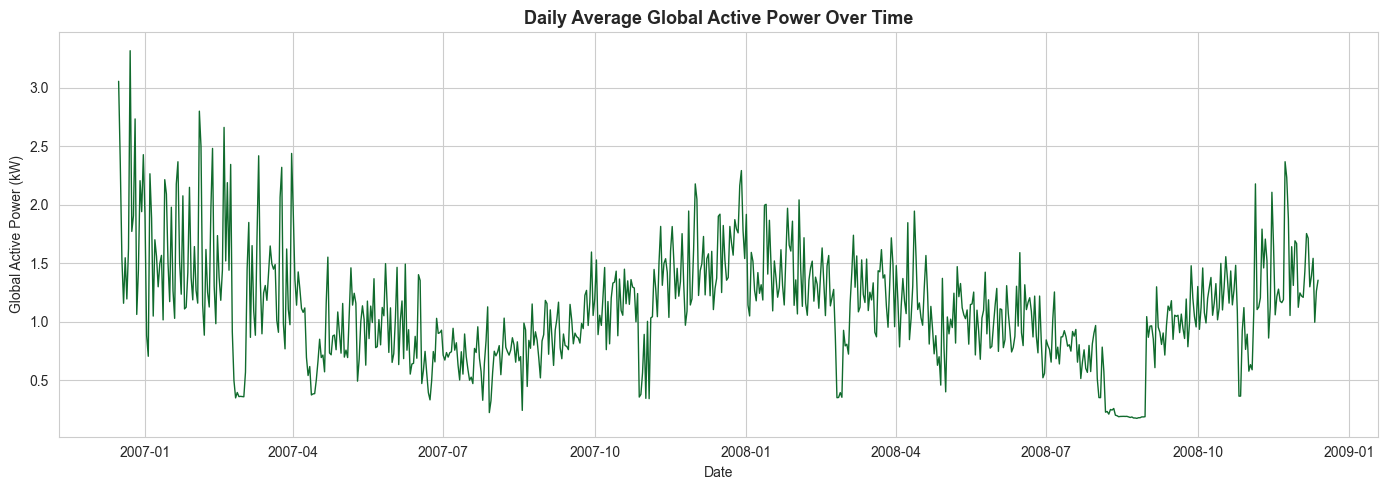

In [11]:
# Overall daily consumption trend
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily['Global_active_power'], color='#106b2d', linewidth=1)
ax.set_title('Daily Average Global Active Power Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.savefig('Plot1_Daily_avg_power.png', bbox_inches='tight')
plt.show()

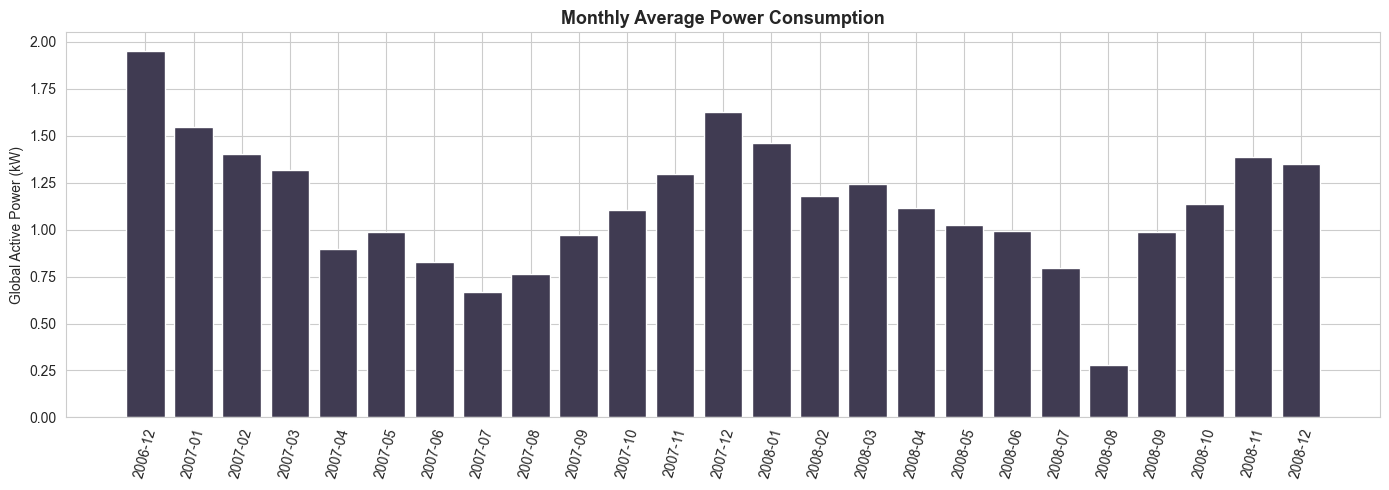

In [12]:
# Monthly seasonality
monthly_avg = daily['Global_active_power'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_avg.index.strftime('%Y-%m'), monthly_avg.values, color='#403b52')
ax.set_title('Monthly Average Power Consumption')
ax.set_ylabel('Global Active Power (kW)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('Plot2_monthly_avg_power_consumption.png', bbox_inches='tight')
plt.show()

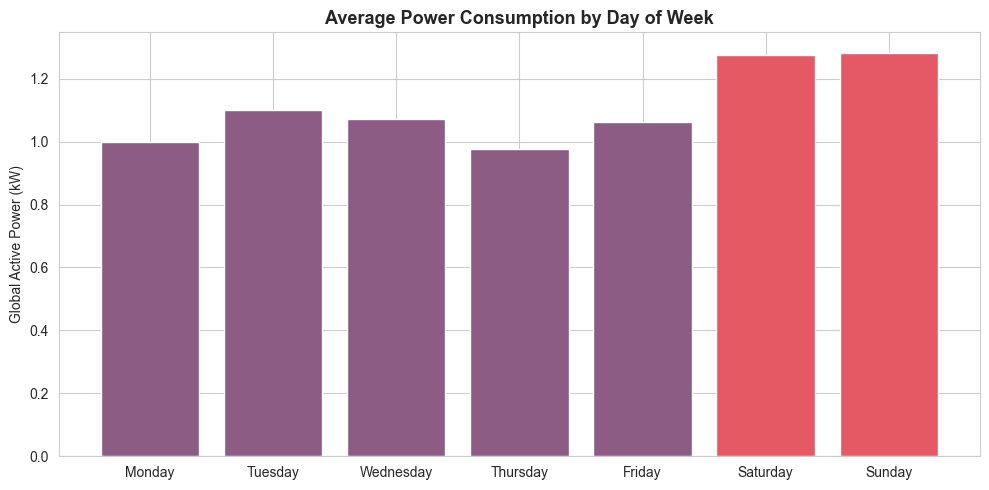

In [13]:
# Weekday vs weekend pattern
weekday_avg = daily.copy()
weekday_avg['dayname'] = weekday_avg.index.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_avg = weekday_avg.groupby('dayname')['Global_active_power'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#8c5c84']*5 + ['#e45964']*2
ax.bar(weekday_avg.index, weekday_avg.values, color=colors)
ax.set_title('Average Power Consumption by Day of Week')
ax.set_ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.savefig('Plot3_avg_power_consumption_dayperweek.png', bbox_inches='tight')
plt.show()

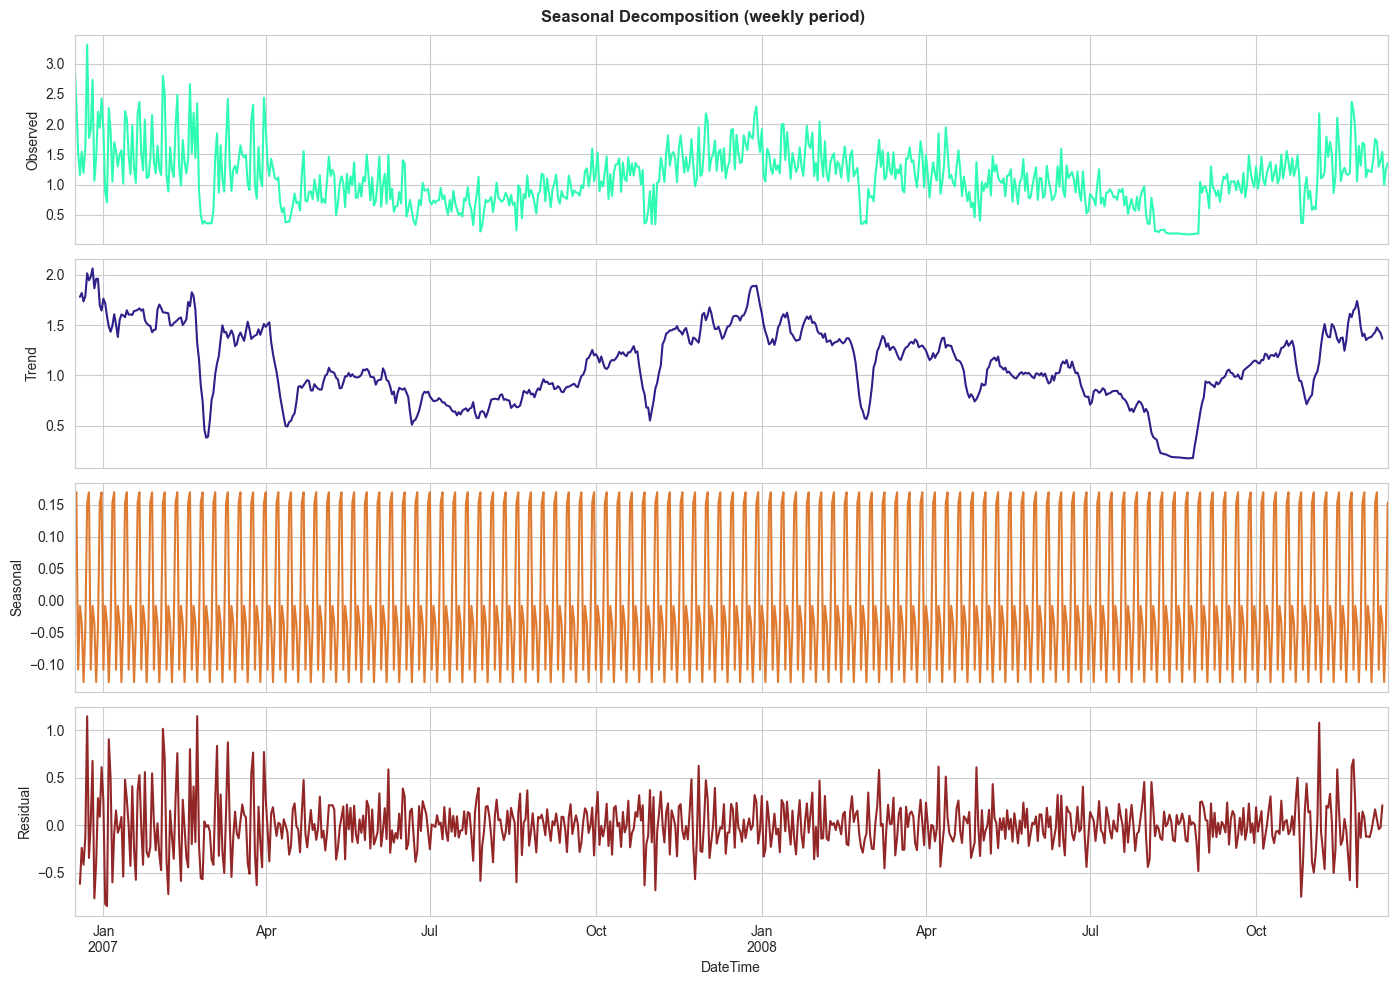

In [14]:
# Seasonal decomposition (trend / seasonality / residual)
decomposition = seasonal_decompose(daily['Global_active_power'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='#30fbb2'); axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='#2d2088'); axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='#df7a31'); axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], color='#932727'); axes[3].set_ylabel('Residual')
fig.suptitle('Seasonal Decomposition (weekly period)', fontweight='bold')
plt.tight_layout()
plt.savefig('Plot4_seasonal_decomposition.png', bbox_inches='tight')
plt.show()

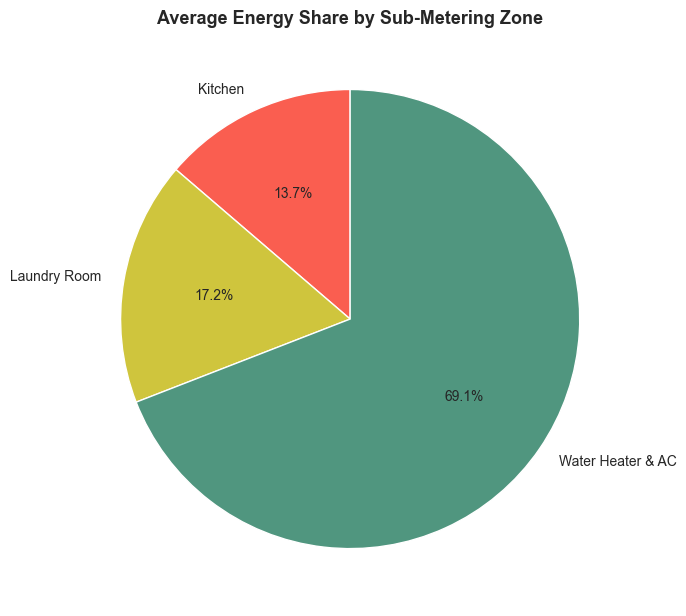

In [16]:
# Sub-metering breakdown
sub_avg = daily[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].mean()
labels = ['Kitchen', 'Laundry Room', 'Water Heater & AC']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sub_avg.values, labels=labels, autopct='%1.1f%%',
       colors=['#fa5e50','#cfc53d','#50967f'], startangle=90)
ax.set_title('Average Energy Share by Sub-Metering Zone')
plt.tight_layout()
plt.savefig('Plot5_avg_energy_submeetingzone.png', bbox_inches='tight')
plt.show()

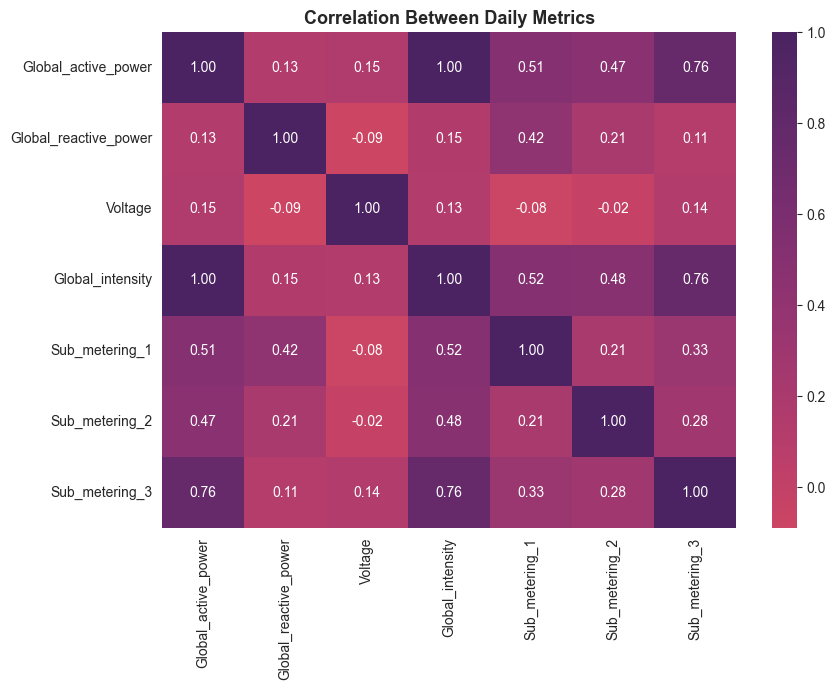

In [19]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = daily.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='flare', center=0, ax=ax)
ax.set_title('Correlation Between Daily Metrics')
plt.tight_layout()
plt.savefig('Plot6_correlation.png', bbox_inches='tight')
plt.show()

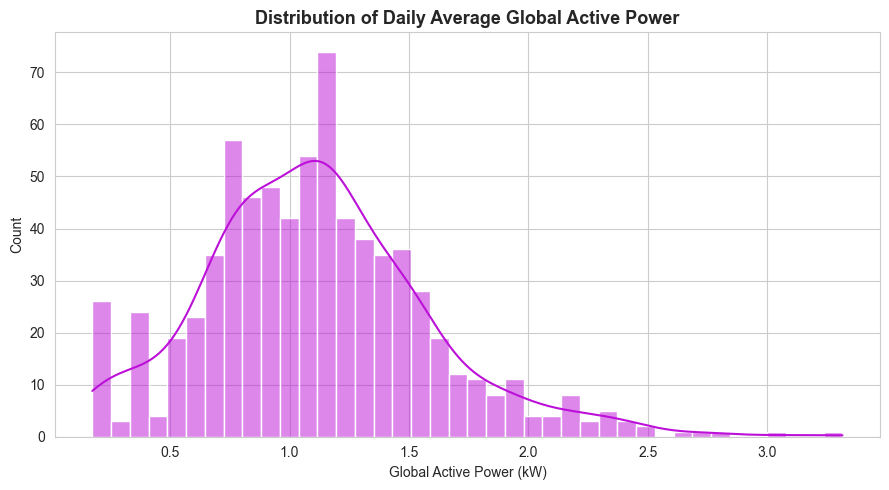

In [24]:
# Distribution of Global Active Power
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(daily['Global_active_power'], bins=40, kde=True, color='#bc10d9', ax=ax)
ax.set_title('Distribution of Daily Average Global Active Power')
ax.set_xlabel('Global Active Power (kW)')
plt.tight_layout()
plt.savefig('Plot7_distribution.png', bbox_inches='tight')
plt.show()

**EDA takeaways:**
- Consumption shows a clear **seasonal (yearly) trend** higher in winter months, lower in summer, consistent with heating demand.
- **Weekends** show noticeably higher average consumption than weekdays, likely due to more time spent at home.
- **Sub-metering 3 (water heater & AC)** typically accounts for the largest share of measured sub-metered energy.
- `Global_intensity` and `Global_active_power` are almost perfectly correlated (as expected physically, since power ≈ voltage × current).

## 5. Model Building and Evaluation

**Task:** Forecast next-day `Global_active_power` using lag features, rolling statistics, and calendar features.

**Approach:** Since this is a time series, we use a **chronological (not random) train/test split** the model is trained on the earlier ~80% of days and evaluated on the most recent ~20%, simulating a real forecasting scenario.

We compare four regression models:
- Linear Regression (baseline)
- Ridge Regression (regularized linear baseline)
- Random Forest Regressor
- Gradient Boosting Regressor

In [25]:
target = 'Global_active_power'
exclude_cols = ['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
features = [c for c in data.columns if c not in exclude_cols]

X = data[features]
y = data[target]

print(f"Features used: {features}")

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data.index[split_idx:]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train period: {data.index[0].date()} → {data.index[split_idx-1].date()}")
print(f"Test period:  {data.index[split_idx].date()} → {data.index[-1].date()}")

Features used: ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14']
Train size: 572  |  Test size: 143
Train period: 2006-12-30 → 2008-07-23
Test period:  2008-07-24 → 2008-12-13


In [26]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                     learning_rate=0.05, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df

,MAE,RMSE,R2
Linear Regression,0.220521,0.298343,0.636217
Ridge Regression,0.221010,0.298826,0.635038
Gradient Boosting,0.264503,0.336788,0.536421
Random Forest,0.266996,0.348152,0.504608


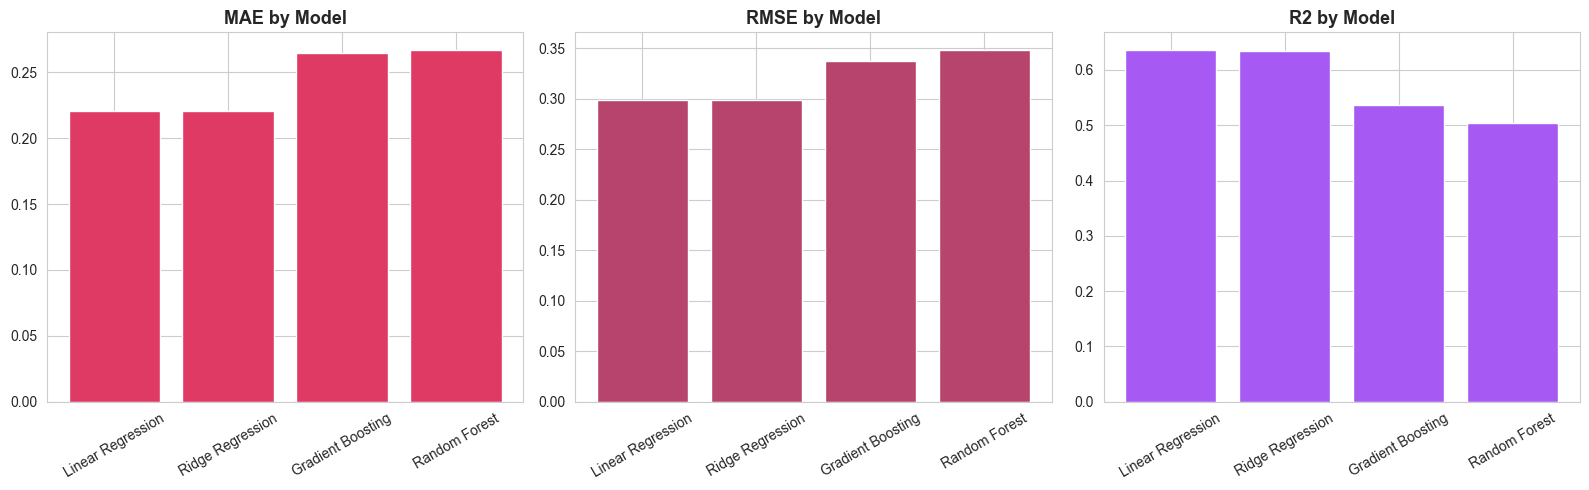

Best model by RMSE: Linear Regression


In [34]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors_map = ['#de3a64', '#b6446d', '#a65af3']

for ax, metric, c in zip(axes, metrics, colors_map):
    ax.bar(results_df.index, results_df[metric], color=c)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('Plot8_model_comparison.png', bbox_inches='tight')
plt.show()

best_model_name = results_df['RMSE'].idxmin()
print(f"Best model by RMSE: {best_model_name}")

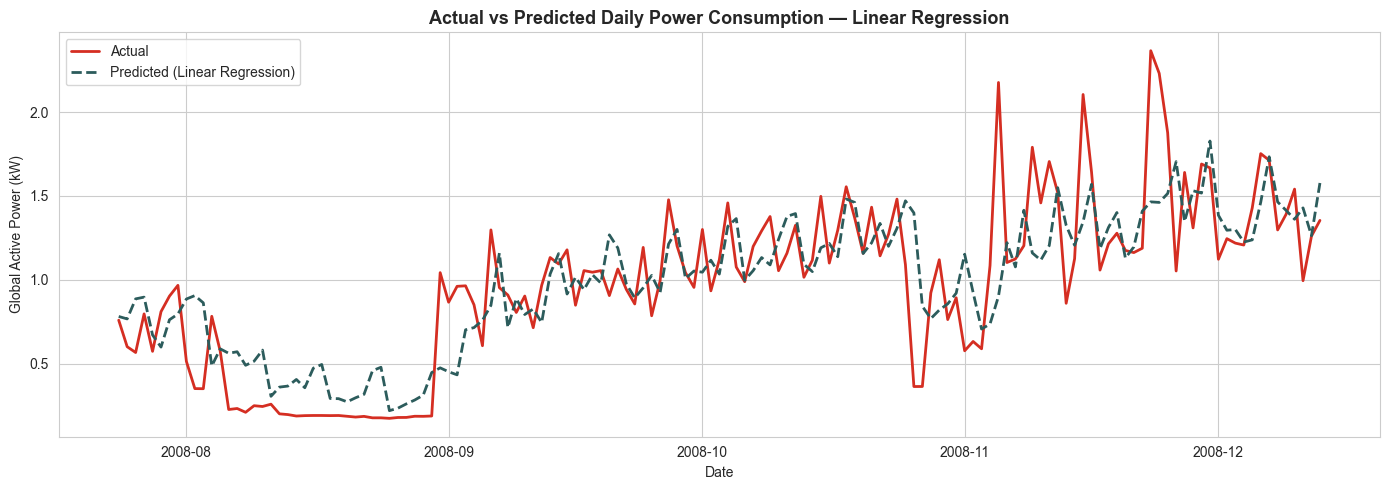

In [36]:
# Actual vs Predicted — best model
best_pred = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test.values, label='Actual', color='#d52e22', linewidth=2)
ax.plot(dates_test, best_pred, label=f'Predicted ({best_model_name})',
        color='#2c5c5c', linewidth=2, linestyle='--')
ax.set_title(f'Actual vs Predicted Daily Power Consumption — {best_model_name}')
ax.set_xlabel('Date')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.tight_layout()
plt.savefig('Plot9_actual_predicted.png', bbox_inches='tight')
plt.show()

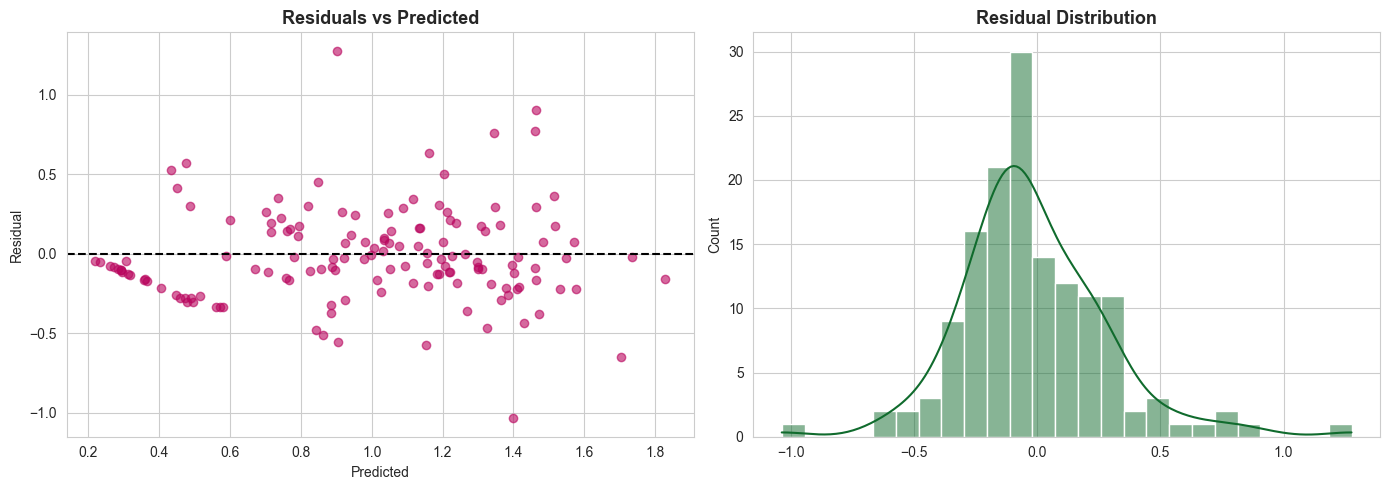

In [43]:
# Residual analysis for the best model
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(best_pred, residuals, alpha=0.6, color='#b9055e')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

sns.histplot(residuals, bins=25, kde=True, color='#106b2d', ax=axes[1])
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.savefig('Plot10_residuals_distri_predicted.png', bbox_inches='tight')
plt.show()

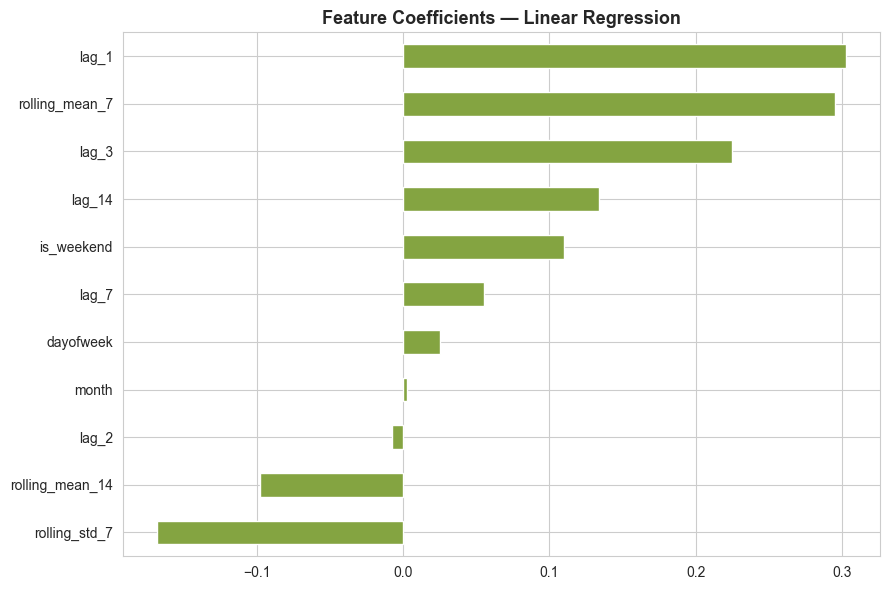

In [44]:
# Feature importance (tree-based model)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = pd.Series(models[best_model_name].feature_importances_, index=features)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.plot(kind='barh', color='#84a441', ax=ax)
    ax.set_title(f'Feature Importance — {best_model_name}')
    plt.tight_layout()
    plt.savefig('Plot11_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    coefs = pd.Series(models[best_model_name].coef_, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(9, 6))
    coefs.plot(kind='barh', color='#84a441', ax=ax)
    ax.set_title(f'Feature Coefficients — {best_model_name}')
    plt.tight_layout()
    plt.savefig('Plot11_feature_coefficients.png', bbox_inches='tight')
    plt.show()

## 6. Visualizations Summary

All charts above (trend lines, seasonal decomposition, weekday/weekend bars, correlation heatmap,
sub-metering pie chart, model comparison, actual-vs-predicted, residuals, and feature importance)
were generated inline as part of the EDA and modeling sections to keep each visualization next to
the analysis it supports.

## 7. Final Conclusion and Insights

### Key Findings
1. **Seasonality dominates:** Household power consumption follows a strong yearly cycle, peaking in winter (heating) and dipping in summer, captured clearly by the seasonal decomposition.
2. **Weekly pattern:** Weekends show higher average consumption than weekdays, reflecting more time spent at home.
3. **Sub-metering 3** (water heater & air conditioning) is consistently the largest contributor to measured sub-metered energy use.
4. **Recent history is the strongest predictor:** Lag features (previous day, previous week) and the 7-day rolling mean carried the most predictive power. Recent consumption behavior is the best guide to near-future consumption.

### Model Performance
The models were evaluated on a chronological hold-out set (most recent ~20% of days). Results are summarized in `results_df` above. Tree-based ensemble models (Random Forest / Gradient Boosting) generally captured non-linear day-to-day patterns better than plain linear regression, while linear/ridge models offered a fast, interpretable baseline.

### Practical Implications
- A short-term (next-day) forecast built from just the last two weeks of consumption history achieves reasonable accuracy, which is useful for **grid load planning** and **personal energy budgeting**.
- Utilities could use this type of model to flag anomalous consumption days (large residuals) for demand-response programs.

### Limitations & Future Work
- Only ~2 years of data limit the ability to confirm multi-year seasonal trends.
- Weather data (temperature, humidity) were not available here but would likely improve forecasts significantly given the clear seasonal effect.
- Hourly (rather than daily) forecasting, or classical time-series models like SARIMA/Prophet, could be explored for finer-grained predictions.
